<a href="https://colab.research.google.com/github/JosephAt10/PCVK_2026/blob/main/Week7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
import math
from google. colab.patches import cv2_imshow
from PIL import Image as im

In [11]:
def convolution2d(image, kernel, stride, padding):
  pass

In [6]:
img = cv. imread('/content/drive/MyDrive/PCVK_2026/Images/mandrill.tiff')
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

In [7]:
#image sharpen
kernel_sharpen = np. array([[0,-1,0],
[-1,5,-1],
[0,-1,0]])

In [13]:
convolution2d(img_gray,kernel_sharpen,1,2)

In [15]:
def convolution2d(image, kernel, stride=1, padding=1):
    image = image.astype(np.float32)
    kernel = np.asarray(kernel, dtype=np.float32)

    # Flip the kernel for mathematical convolution
    kernel = np.flip(kernel, axis=(0, 1))

    padded = np.pad(
        image,
        ((padding, padding), (padding, padding)),
        mode="constant"
    )

    out_height = (padded.shape[0] - kernel.shape[0]) // stride + 1
    out_width = (padded.shape[1] - kernel.shape[1]) // stride + 1
    output = np.zeros((out_height, out_width), dtype=np.float32)

    for y in range(out_height):
        for x in range(out_width):
            y_start = y * stride
            x_start = x * stride

            region = padded[
                y_start:y_start + kernel.shape[0],
                x_start:x_start + kernel.shape[1]
            ]

            output[y, x] = np.sum(region * kernel)

    return output

In [16]:
kernels = {
    "Average": np.ones((3, 3), dtype=np.float32) / 9,

    "Low-pass": np.array([
        [1, 2, 1],
        [2, 4, 2],
        [1, 2, 1]
    ], dtype=np.float32) / 16,

    "High-pass": np.array([
        [-1, -1, -1],
        [-1,  8, -1],
        [-1, -1, -1]
    ], dtype=np.float32),

    "Sharpen": np.array([
        [ 0, -1,  0],
        [-1,  5, -1],
        [ 0, -1,  0]
    ], dtype=np.float32),

    "Emboss": np.array([
        [-2, -1,  0],
        [-1,  1,  1],
        [ 0,  1,  2]
    ], dtype=np.float32),

    "Left Sobel": np.array([
        [1,  0, -1],
        [2,  0, -2],
        [1,  0, -1]
    ], dtype=np.float32)
}

In [17]:
results = {}

for name, kernel in kernels.items():
    response = convolution2d(img_gray, kernel, stride=1, padding=1)

    if name == "High-pass":
        # Show the strength of edges, including negative responses
        result = cv.normalize(
            np.abs(response), None, 0, 255, cv.NORM_MINMAX
        ).astype(np.uint8)

    elif name == "Left Sobel":
        # Absolute value makes both edge directions visible
        result = cv.normalize(
            np.abs(response), None, 0, 255, cv.NORM_MINMAX
        ).astype(np.uint8)

    elif name == "Emboss":
        result = np.clip(response + 128, 0, 255).astype(np.uint8)

    else:
        result = np.clip(response, 0, 255).astype(np.uint8)

    results[name] = result

In [18]:
canny_result = cv.Canny(img_gray, threshold1=100, threshold2=200)
results["Canny"] = canny_result

In [19]:
kernel_size = 21
sigma = math.sqrt(kernel_size)

# Generate the 1D Gaussian kernel, then make it 2D
gaussian_1d = cv.getGaussianKernel(kernel_size, sigma)
gaussian_2d = gaussian_1d @ gaussian_1d.T

# Apply the blur using OpenCV
gaussian_result = cv.GaussianBlur(
    img_gray,
    (kernel_size, kernel_size),
    sigma
)

results["21×21 Gaussian Blur"] = gaussian_result

print("21×21 Gaussian kernel:")
print(gaussian_2d)

21×21 Gaussian kernel:
[[6.76977605e-05 1.06424313e-04 1.59524251e-04 2.27998446e-04
  3.10710815e-04 4.03738498e-04 5.00222550e-04 5.90943118e-04
  6.65652249e-04 7.14938094e-04 7.32164694e-04 7.14938094e-04
  6.65652249e-04 5.90943118e-04 5.00222550e-04 4.03738498e-04
  3.10710815e-04 2.27998446e-04 1.59524251e-04 1.06424313e-04
  6.76977605e-05]
 [1.06424313e-04 1.67304416e-04 2.50780213e-04 3.58425119e-04
  4.88453157e-04 6.34697392e-04 7.86375215e-04 9.28992549e-04
  1.04643909e-03 1.12391894e-03 1.15100003e-03 1.12391894e-03
  1.04643909e-03 9.28992549e-04 7.86375215e-04 6.34697392e-04
  4.88453157e-04 3.58425119e-04 2.50780213e-04 1.67304416e-04
  1.06424313e-04]
 [1.59524251e-04 2.50780213e-04 3.75905888e-04 5.37259743e-04
  7.32164694e-04 9.51376842e-04 1.17873364e-03 1.39250926e-03
  1.56855524e-03 1.68469331e-03 1.72528639e-03 1.68469331e-03
  1.56855524e-03 1.39250926e-03 1.17873364e-03 9.51376842e-04
  7.32164694e-04 5.37259743e-04 3.75905888e-04 2.50780213e-04
  1.5952425

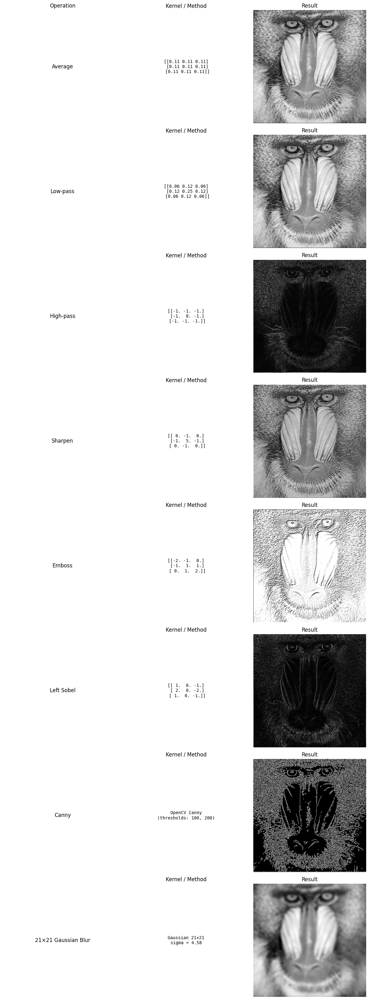

In [20]:
display_order = [
    "Average",
    "Low-pass",
    "High-pass",
    "Sharpen",
    "Emboss",
    "Left Sobel",
    "Canny",
    "21×21 Gaussian Blur"
]

fig, axes = plt.subplots(
    len(display_order), 3,
    figsize=(12, 4 * len(display_order))
)

for row, name in enumerate(display_order):
    axes[row, 0].text(
        0.5, 0.5, name,
        ha="center", va="center", fontsize=12
    )
    axes[row, 0].axis("off")

    if name in kernels:
        kernel_text = np.array2string(kernels[name], precision=2)
    elif name == "Canny":
        kernel_text = "OpenCV Canny\n(thresholds: 100, 200)"
    else:
        kernel_text = f"Gaussian 21×21\nsigma = {sigma:.2f}"

    axes[row, 1].text(
        0.5, 0.5, kernel_text,
        ha="center", va="center", family="monospace", fontsize=10
    )
    axes[row, 1].set_title("Kernel / Method")
    axes[row, 1].axis("off")

    axes[row, 2].imshow(results[name], cmap="gray")
    axes[row, 2].set_title("Result")
    axes[row, 2].axis("off")

axes[0, 0].set_title("Operation")
plt.tight_layout()
plt.show()

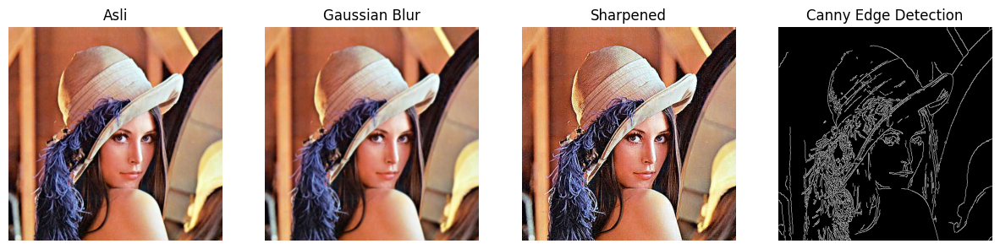

In [33]:
# Fungsi tampil berdampingan
def show_side_by_side(images, titles, figsize=(15,5)):
    plt.figure(figsize=figsize)
    for i, (img, title) in enumerate(zip(images, titles)):
        if len(img.shape) == 2:  # grayscale
            plt.subplot(1, len(images), i+1)
            plt.imshow(img, cmap="gray")
        else:  # color
            plt.subplot(1, len(images), i+1)
            plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
        plt.title(title)
        plt.axis("off")
    plt.show()

img = cv.imread("/content/drive/MyDrive/PCVK_2026/Images/lena.jpg")
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

blur = cv.GaussianBlur(img, (7,7), 1)
edges = cv.Canny(cv.cvtColor(img, cv.COLOR_BGR2GRAY), 100, 200)
sharpen_kernel = np.array([[0,-1,0],[-1,5,-1],[0,-1,0]])
sharpened = cv.filter2D(img, -1, sharpen_kernel)
show_side_by_side([img, blur, sharpened, edges],
                  ["Asli", "Gaussian Blur", "Sharpened", "Canny Edge Detection"])

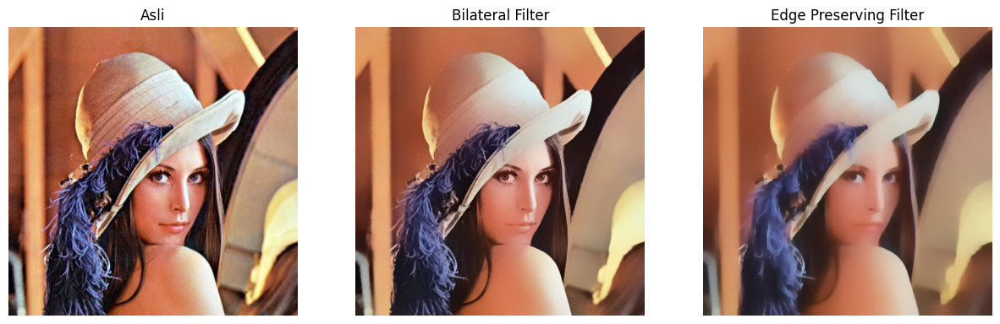

In [24]:
#Filter Modern dari OpenCV
# Bilateral Filter (edge-preserving)
bilateral = cv.bilateralFilter(img, 50, 100, 100)

# Edge Preserving Filter (alternatif Guided Filter)
edge_preserve = cv.edgePreservingFilter(img, flags=1, sigma_s=100, sigma_r=0.9)

show_side_by_side([img, bilateral, edge_preserve],
["Asli", "Bilateral Filter", "Edge Preserving Filter"])

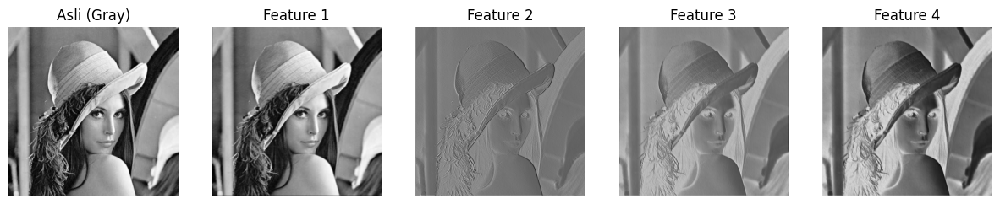

In [26]:
#Filter Feature Map yang digunakan pada CNN, Lakukan running code bagian ini beberapa kali dan perhatikan hasilnya
import torch
import torch.nn as nn

class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 4, kernel_size=3, stride=1, padding=1)

    def forward(self, x):
        return self.conv1(x)

model = SimpleCNN()

# Ubah gambar ke tensor
img_tensor = torch.tensor(img_gray, dtype=torch.float32).unsqueeze(0).unsqueeze(0) / 255.0

# Hasil CNN
with torch.no_grad():
    features = model(img_tensor)

# Visualisasi feature maps
feature_maps = [features[0,i].numpy() for i in range(features.shape[1])]
show_side_by_side([img_gray] + feature_maps, ["Asli (Gray)"] + [f"Feature {i+1}" for i in range(len(feature_maps))])

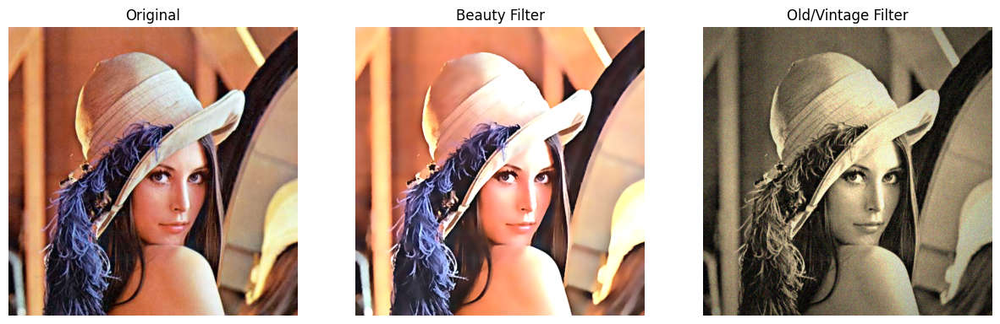

In [29]:
# ====================
# 1. Beauty Filter
# ====================
# Step 1: Smoothing kulit dengan bilateral filter
smooth = cv.bilateralFilter(img, d=15, sigmaColor=75, sigmaSpace=75)

# Step 2: Unsharp masking (pertajam mata/bibir)
gaussian = cv.GaussianBlur(smooth, (0,0), 3)
sharpened = cv.addWeighted(smooth, 1.5, gaussian, -0.5, 0)

# Step 3: Brightness & contrast
alpha = 1.2  # contrast
beta = 15    # brightness
beauty = cv.convertScaleAbs(sharpened, alpha=alpha, beta=beta)

# ====================
# 2. Old/Vintage Filter
# ====================
# Step 1: Sepia tone
sepia_kernel = np.array([[0.272, 0.534, 0.131],
                         [0.349, 0.686, 0.168],
                         [0.393, 0.769, 0.189]])
sepia = cv.transform(img, sepia_kernel)
sepia = np.clip(sepia, 0, 255).astype(np.uint8)

# Step 2: Vignette
rows, cols = img.shape[:2]
kernel_x = cv.getGaussianKernel(cols, cols*0.6)
kernel_y = cv.getGaussianKernel(rows, rows*0.6)
kernel = kernel_y * kernel_x.T
mask = kernel / kernel.max()
vignette = np.copy(sepia)
for i in range(3):
    vignette[:,:,i] = vignette[:,:,i] * mask

# Step 3: Noise/Grain
noise = np.random.normal(0, 15, vignette.shape).astype(np.int16)
old_img = np.clip(vignette.astype(np.int16) + noise, 0, 255).astype(np.uint8)

show_side_by_side(
    [img, beauty, old_img],
    ["Original", "Beauty Filter", "Old/Vintage Filter"]
)

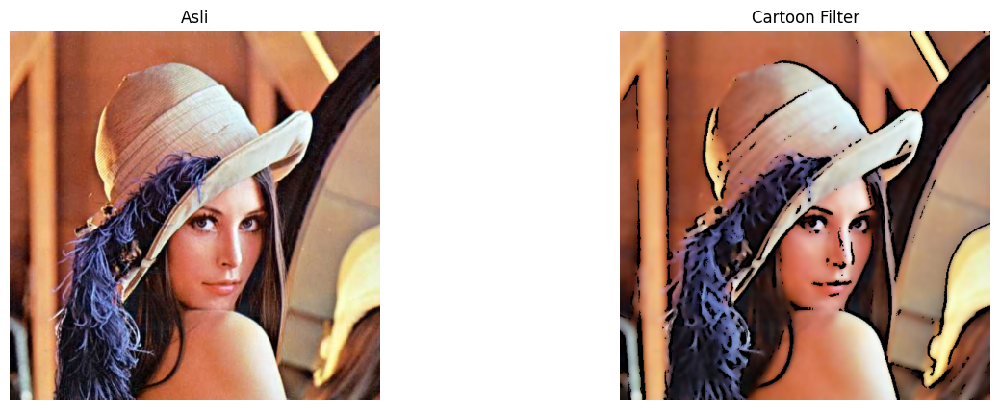

In [34]:
# Filter Anime / Cartoon

# Step 1: Edge detection (pakai median blur dulu agar gambar menjadi lebih halus)
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
gray_blur = cv.medianBlur(gray, 7)
edges = cv.adaptiveThreshold(
    gray_blur,
    255,
    cv.ADAPTIVE_THRESH_MEAN_C,
    cv.THRESH_BINARY,
    9,
    9
)

# Step 2: Bilateral filter untuk smoothing warna
color = cv.bilateralFilter(img, d=9, sigmaColor=200, sigmaSpace=200)

# Step 3: Gabungkan (cartoonize)
cartoon = cv.bitwise_and(color, color, mask=edges)

# Tampilkan
show_side_by_side([img, cartoon], ["Asli", "Cartoon Filter"])

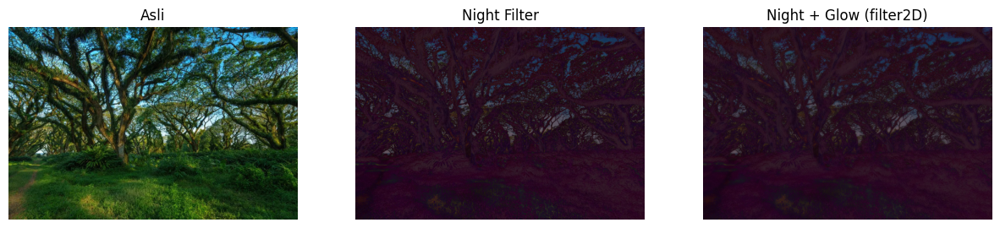

In [35]:
#Night Filter
img = cv.imread("/content/drive/MyDrive/PCVK_2026/Images/djawatan.jpg")
img_gray = cv.cvtColor(img,cv.COLOR_BGR2GRAY)

# Step 1: Gelapkan (contrast turun, brightness negatif)
night = cv.convertScaleAbs(img, alpha=0.6, beta=-40)

# Step 2: Tambah bias biru
blue_tint = np.full_like(night, (50, 0, 100))  # BGR
night = cv.addWeighted(night, 0.8, blue_tint, 0.2, 0)

# Step 3: Efek glow di area terang dengan filter2D (blur kernel)
kernel = np.ones((15,15), np.float32) / 225
glow = cv.filter2D(night, -1, kernel)

# Kombinasikan asli + glow
night_glow = cv.addWeighted(night, 0.7, glow, 0.3, 0)

show_side_by_side([img, night, night_glow],
                  ["Asli", "Night Filter", "Night + Glow (filter2D)"])

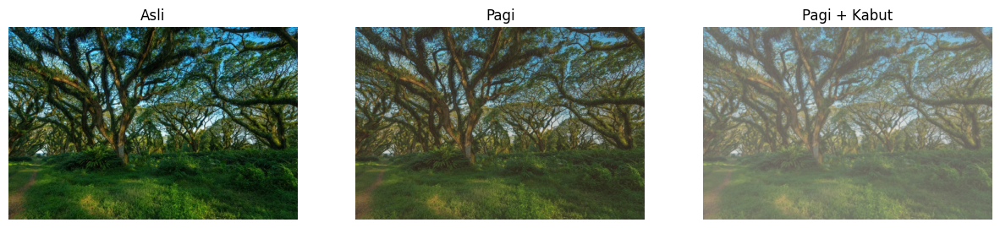

In [36]:
# Filter Suasana pagi dan Kabut
# =============================
# Step 1: Kurangi kontras & cerahkan
# =============================
alpha = 0.9  # contrast
beta = 20    # brightness
soft = cv.convertScaleAbs(img, alpha=alpha, beta=beta)

# =============================
# Step 2: Tambahkan warm tone (kemerahan / oranye)
# =============================
warm_tint = np.full_like(soft, (40, 70, 120))  # BGR
pagi = cv.addWeighted(soft, 0.8, warm_tint, 0.2, 0)

# =============================
# Step 3: Tambahkan haze (kabut tipis) dengan filter2D
# =============================
# Kernel blur Gaussian-like untuk menciptakan efek kabut
kernel = cv.getGaussianKernel(3, 3)
kernel = kernel @ kernel.T  # jadikan 2D kernel
kabut = cv.filter2D(pagi, -1, kernel)

# Tambah layer putih untuk kabut lebih nyata
white_layer = np.full_like(pagi, 255)
kabut = cv.addWeighted(kabut, 0.7, white_layer, 0.3, 0)

show_side_by_side([img, pagi, kabut],
                  ["Asli", "Pagi", "Pagi + Kabut"])

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

image_path = '/content/drive/MyDrive/PCVK_2026/Images/mandrill.tiff'

img = cv.imread(image_path)

if img is None:
    raise FileNotFoundError(f"Image not found: {image_path}")

img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

Mounted at /content/drive


In [2]:
def show_side_by_side(images, titles, figsize=(16, 5)):
    plt.figure(figsize=figsize)

    for i, (image, title) in enumerate(zip(images, titles)):
        plt.subplot(1, len(images), i + 1)

        if len(image.shape) == 2:
            plt.imshow(image, cmap="gray")
        else:
            plt.imshow(cv.cvtColor(image, cv.COLOR_BGR2RGB))

        plt.title(title)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

In [3]:
def add_salt_and_pepper(image, amount=0.06, seed=42):
    rng = np.random.default_rng(seed)
    noisy = image.copy()
    random_values = rng.random(image.shape)

    noisy[random_values < amount / 2] = 0
    noisy[(random_values >= amount / 2) & (random_values < amount)] = 255

    return noisy


noisy_gray = add_salt_and_pepper(img_gray, amount=0.06)

In [4]:
mean_filtered = cv.blur(noisy_gray, (3, 3))
median_filtered = cv.medianBlur(noisy_gray, 3)

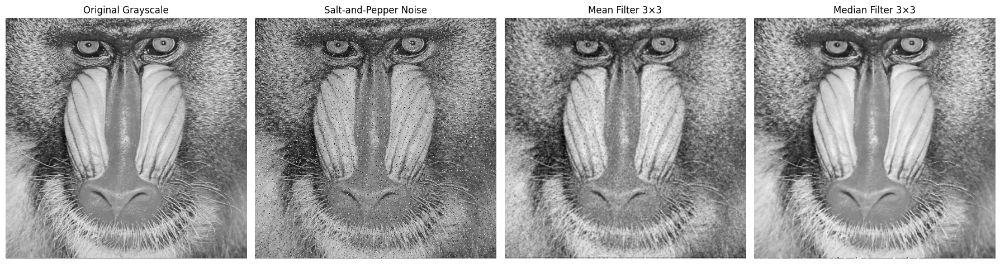

In [5]:
show_side_by_side(
    [img_gray, noisy_gray, mean_filtered, median_filtered],
    ["Original Grayscale", "Salt-and-Pepper Noise",
     "Mean Filter 3×3", "Median Filter 3×3"],
    figsize=(18, 5)
)

In [6]:
blurred = cv.GaussianBlur(img, (5, 5), 1.2)

rng = np.random.default_rng(42)
small_noise = rng.normal(0, 3, blurred.shape)

blurred_noisy = np.clip(
    blurred.astype(np.float32) + small_noise,
    0,
    255
).astype(np.uint8)

In [7]:
sharpen_kernel_3 = np.array([
    [ 0, -1,  0],
    [-1,  5, -1],
    [ 0, -1,  0]
], dtype=np.float32)

gaussian_5 = cv.getGaussianKernel(5, 1.0)
blur_kernel_5 = gaussian_5 @ gaussian_5.T

sharpen_kernel_5 = -blur_kernel_5
sharpen_kernel_5[2, 2] += 2.0

In [8]:
sharpened_3 = cv.filter2D(
    blurred_noisy, cv.CV_32F, sharpen_kernel_3
)
sharpened_3 = np.clip(sharpened_3, 0, 255).astype(np.uint8)

sharpened_5 = cv.filter2D(
    blurred_noisy, cv.CV_32F, sharpen_kernel_5
)
sharpened_5 = np.clip(sharpened_5, 0, 255).astype(np.uint8)

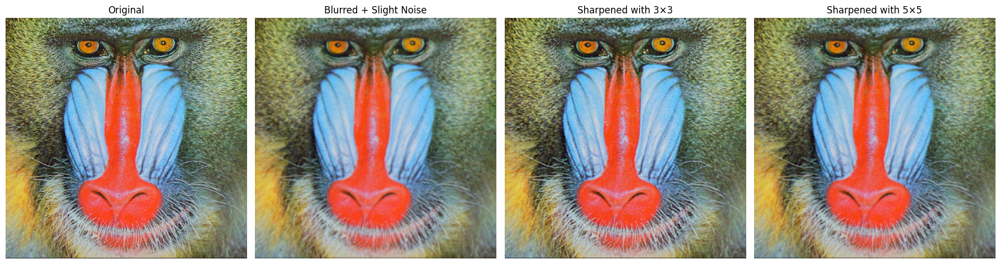

In [9]:
show_side_by_side(
    [img, blurred_noisy, sharpened_3, sharpened_5],
    ["Original", "Blurred + Slight Noise",
     "Sharpened with 3×3", "Sharpened with 5×5"],
    figsize=(18, 5)
)

In [10]:
def cartoon(image):
    # Smooth colors while preserving edges
    smooth_color = cv.bilateralFilter(
        image, d=9, sigmaColor=200, sigmaSpace=200
    )
    smooth_color = cv.bilateralFilter(
        smooth_color, d=9, sigmaColor=200, sigmaSpace=200
    )

    # Detect edges with adaptive thresholding
    gray = cv.cvtColor(image, cv.COLOR_BGR2GRAY)
    gray_blur = cv.medianBlur(gray, 7)

    edges = cv.adaptiveThreshold(
        gray_blur,
        255,
        cv.ADAPTIVE_THRESH_MEAN_C,
        cv.THRESH_BINARY,
        9,
        9
    )

    # Combine the smoothed color image and edge mask
    cartoon_image = cv.bitwise_and(
        smooth_color, smooth_color, mask=edges
    )

    return cartoon_image


cartoon_img = cartoon(img)

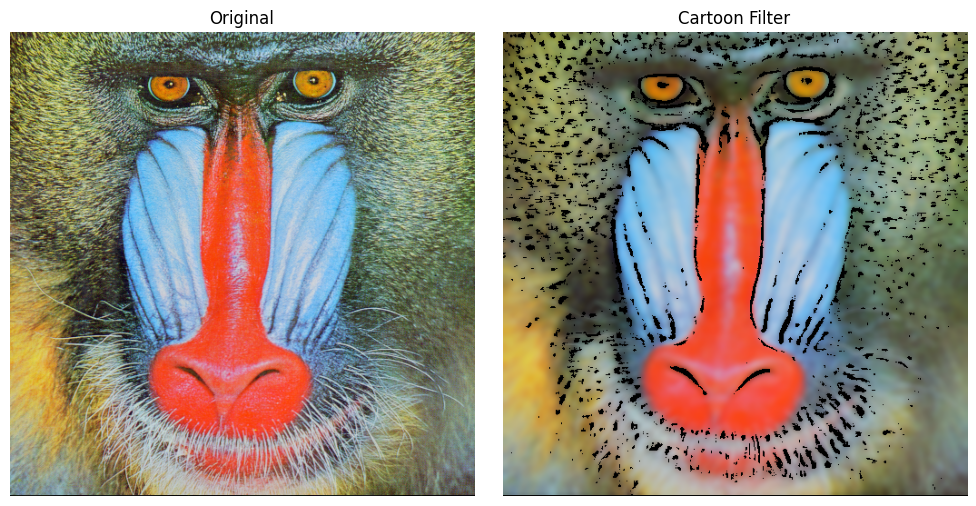

In [12]:
show_side_by_side(
    [img, cartoon_img],
    ["Original", "Cartoon Filter"],
    figsize=(10, 5)
)